In [ ]:
!pip install matplotlib
!pip install seaborn
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns


In [2]:
file_path = "../transactions.parquet"
# open dataset
df = pd.read_parquet(file_path, engine='pyarrow')
print("Read file")

Read file


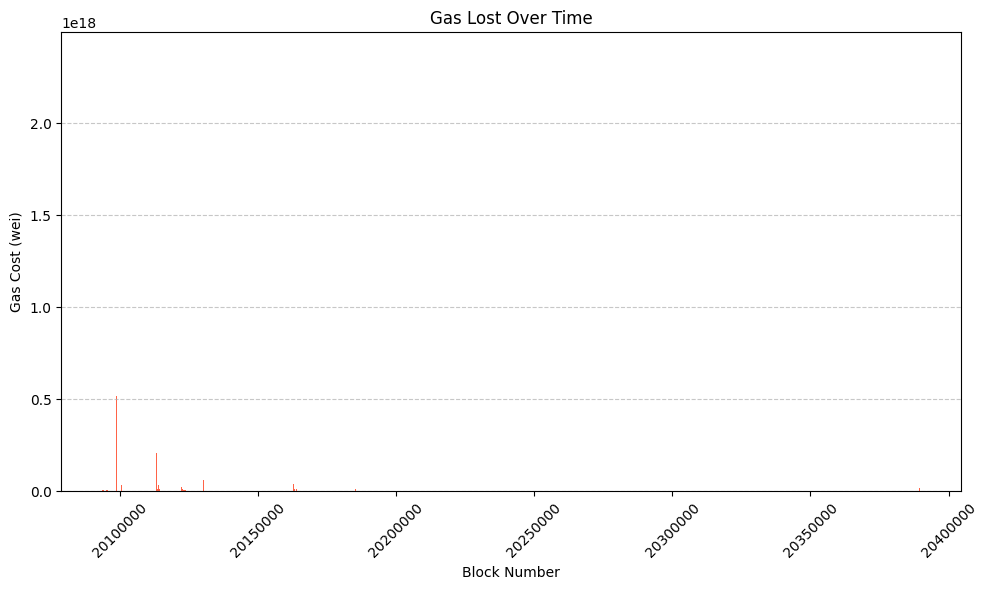

In [3]:
def plot_gas_lost_per_block(df, rolling_window=50):
    out_of_gas_df = df
    out_of_gas_df.loc[:, "gas_cost"] = out_of_gas_df["gas"] * out_of_gas_df["gas_price"]
    gas_lost_by_block = out_of_gas_df.groupby("block_number")["gas_cost"].sum().sort_index()
    gas_lost_smoothed = gas_lost_by_block.rolling(window=rolling_window, min_periods=1).mean()

    plt.figure(figsize=(10, 6), dpi=100)
    plt.ylim(0, gas_lost_smoothed.max() * 1.1)
    plt.bar(gas_lost_smoothed.index, gas_lost_smoothed.values, color='tomato', width=1.0)

    plt.title("Gas Lost Over Time")
    plt.xlabel("Block Number")
    plt.ylabel("Gas Cost (wei)")

    # Ensure full block numbers are displayed
    plt.gca().xaxis.set_major_formatter(ticker.FormatStrFormatter('%d'))
    plt.xticks(rotation=45)

    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

plot_gas_lost_per_block(df)

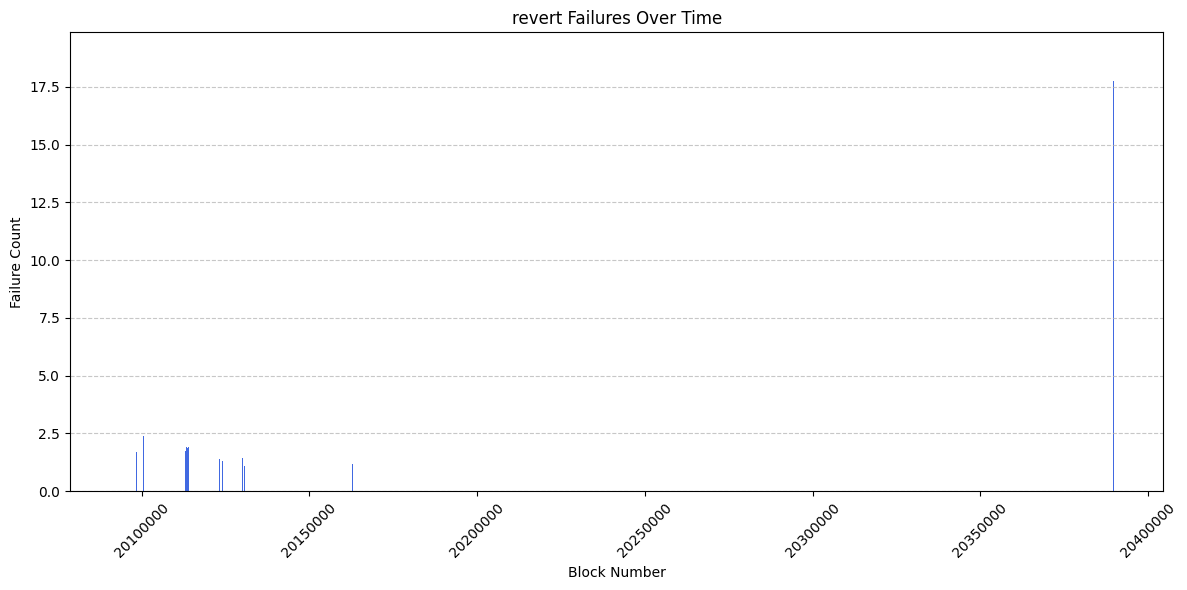

In [34]:
def plot_invariant_count(df, invariant, rolling_window=50):
    df = df[df["failure_invariant"].str.contains(invariant, case=False, na=False)]
    failures_by_block = df.groupby("block_number").size().sort_index()
    failures_smoothed = failures_by_block.rolling(window=rolling_window, min_periods=1).mean()

    plt.figure(figsize=(12, 6))
    plt.bar(failures_smoothed.index, failures_smoothed.values, color='royalblue', width=1.0)

    plt.title(f"{invariant} Failures Over Time")
    plt.xlabel("Block Number")
    plt.ylabel("Failure Count")

    plt.gca().xaxis.set_major_formatter(ticker.FormatStrFormatter('%d'))
    plt.xticks(rotation=45)

    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
plot_invariant_count(df, "revert")


C:\Users\Melis\AppData\Local\Temp\ipykernel_29020\1594694579.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='failed_count', y='from_address', data=from_address_df, ax=axes[0], palette='Blues_d')
C:\Users\Melis\AppData\Local\Temp\ipykernel_29020\1594694579.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='failed_count', y='to_address', data=to_address_df, ax=axes[1], palette='Reds_d')


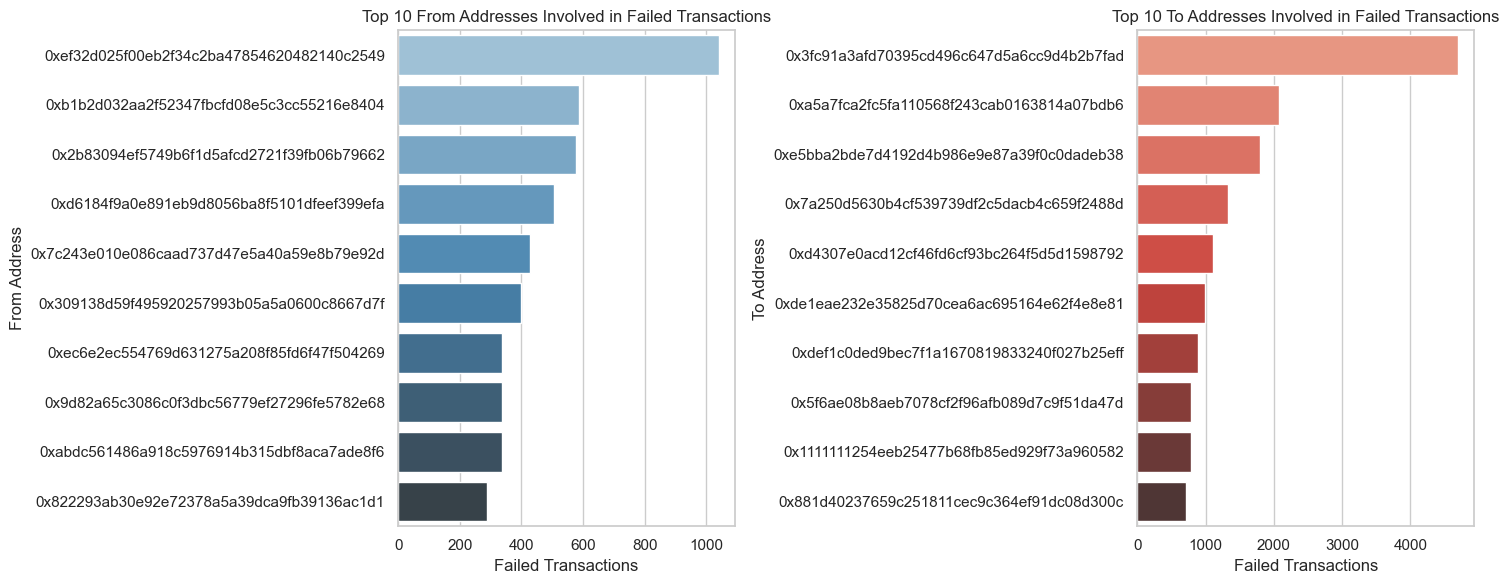

In [8]:
def plot_most_common_from_and_to_addresses(df):
    from_address_counts = df['from_address'].value_counts().head(10)  # Top 10 'from_address'
    to_address_counts = df['to_address'].value_counts().head(10)  # Top 10 'to_address'

    from_address_df = from_address_counts.reset_index()
    from_address_df.columns = ['from_address', 'failed_count']

    to_address_df = to_address_counts.reset_index()
    to_address_df.columns = ['to_address', 'failed_count']

    sns.set(style="whitegrid")

    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    sns.barplot(x='failed_count', y='from_address', data=from_address_df, ax=axes[0], palette='Blues_d')
    axes[0].set_title('Top 10 From Addresses Involved in Failed Transactions')
    axes[0].set_xlabel('Failed Transactions')
    axes[0].set_ylabel('From Address')

    sns.barplot(x='failed_count', y='to_address', data=to_address_df, ax=axes[1], palette='Reds_d')
    axes[1].set_title('Top 10 To Addresses Involved in Failed Transactions')
    axes[1].set_xlabel('Failed Transactions')
    axes[1].set_ylabel('To Address')

    # Adjust layout to avoid overlapping labels
    plt.tight_layout()

    # Show the plot
    plt.show()

plot_most_common_from_and_to_addresses(df)

C:\Users\Melis\AppData\Local\Temp\ipykernel_25120\1669887041.py:20: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


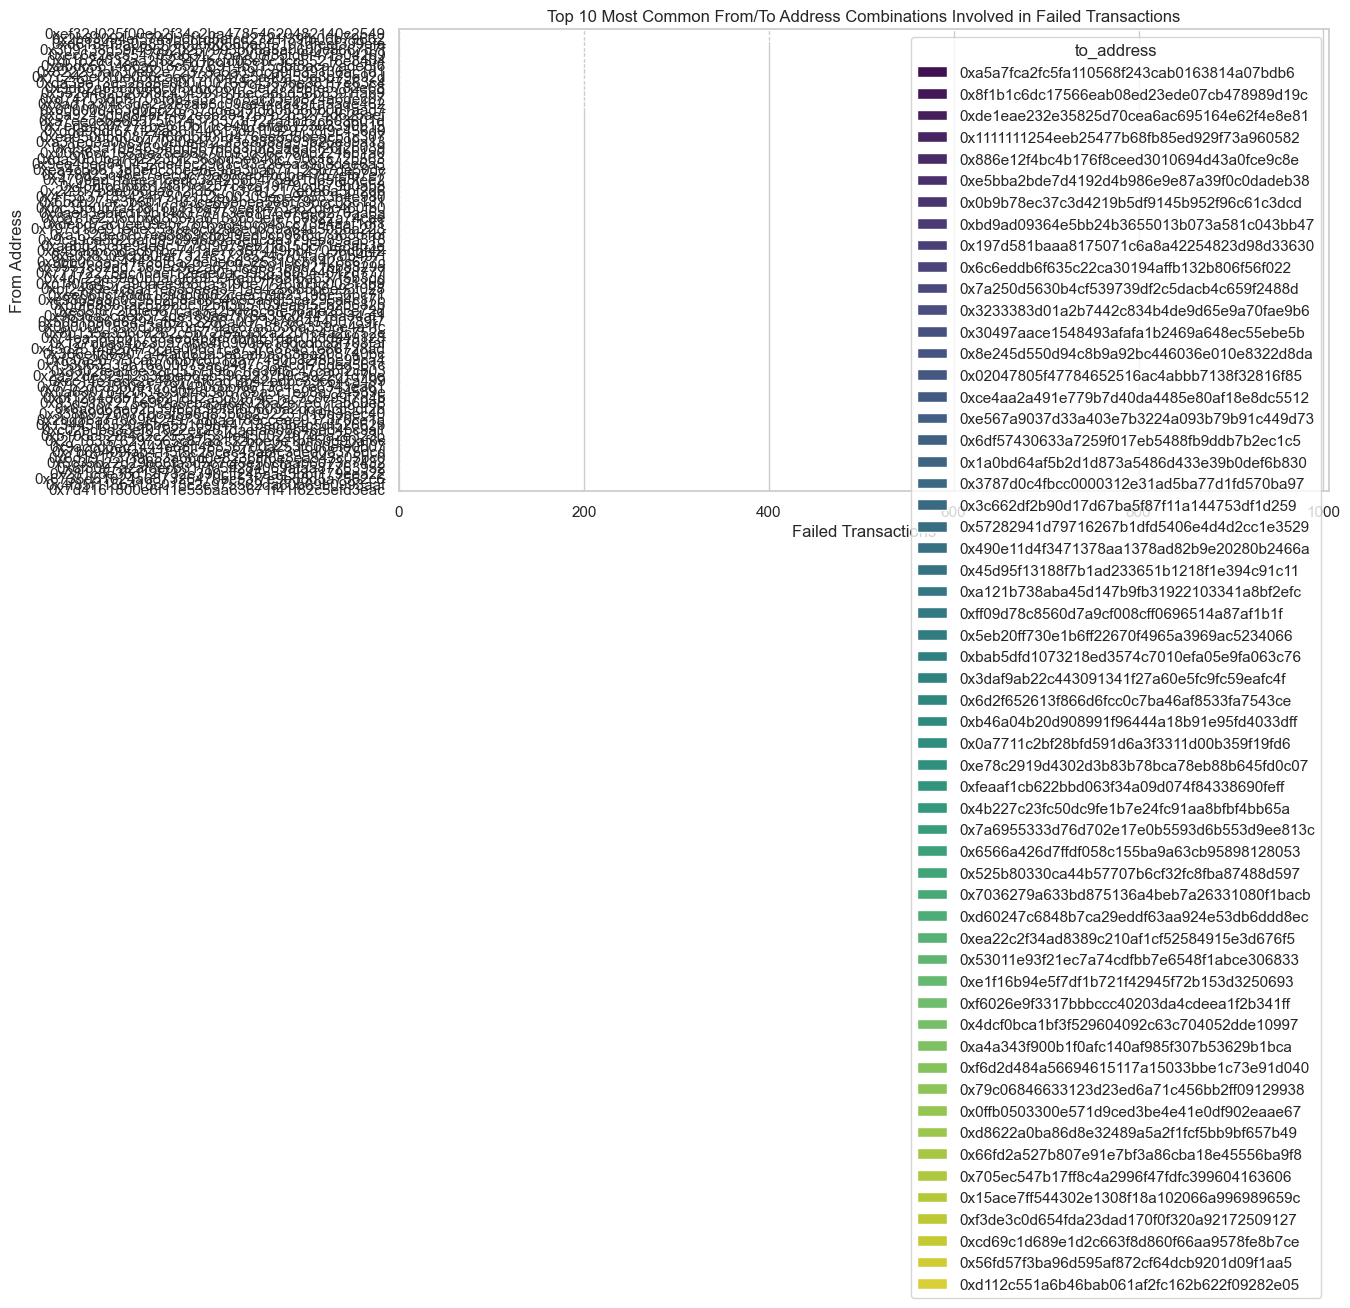

In [45]:
def plot_most_common_transactions(df):
    # Count the occurrences of each unique pair of (from_address, to_address)
    transaction_counts = df.groupby(['from_address', 'to_address']).size().reset_index(name='failed_count')

    # Sort the counts to get the top 10 most common transactions
    top_transactions = transaction_counts.sort_values(by='failed_count', ascending=False).head(100)

    # Set seaborn style
    sns.set(style="whitegrid")

    # Plot the most common transactions (from_address with to_address)
    plt.figure(figsize=(12, 6))
    sns.barplot(x='failed_count', y='from_address', hue='to_address', data=top_transactions, palette='viridis')

    plt.title('Top 10 Most Common From/To Address Combinations Involved in Failed Transactions')
    plt.xlabel('Failed Transactions')
    plt.ylabel('From Address')

    # Adjust layout for better spacing
    plt.tight_layout()

    # Show the plot
    plt.show()

plot_most_common_transactions(df)


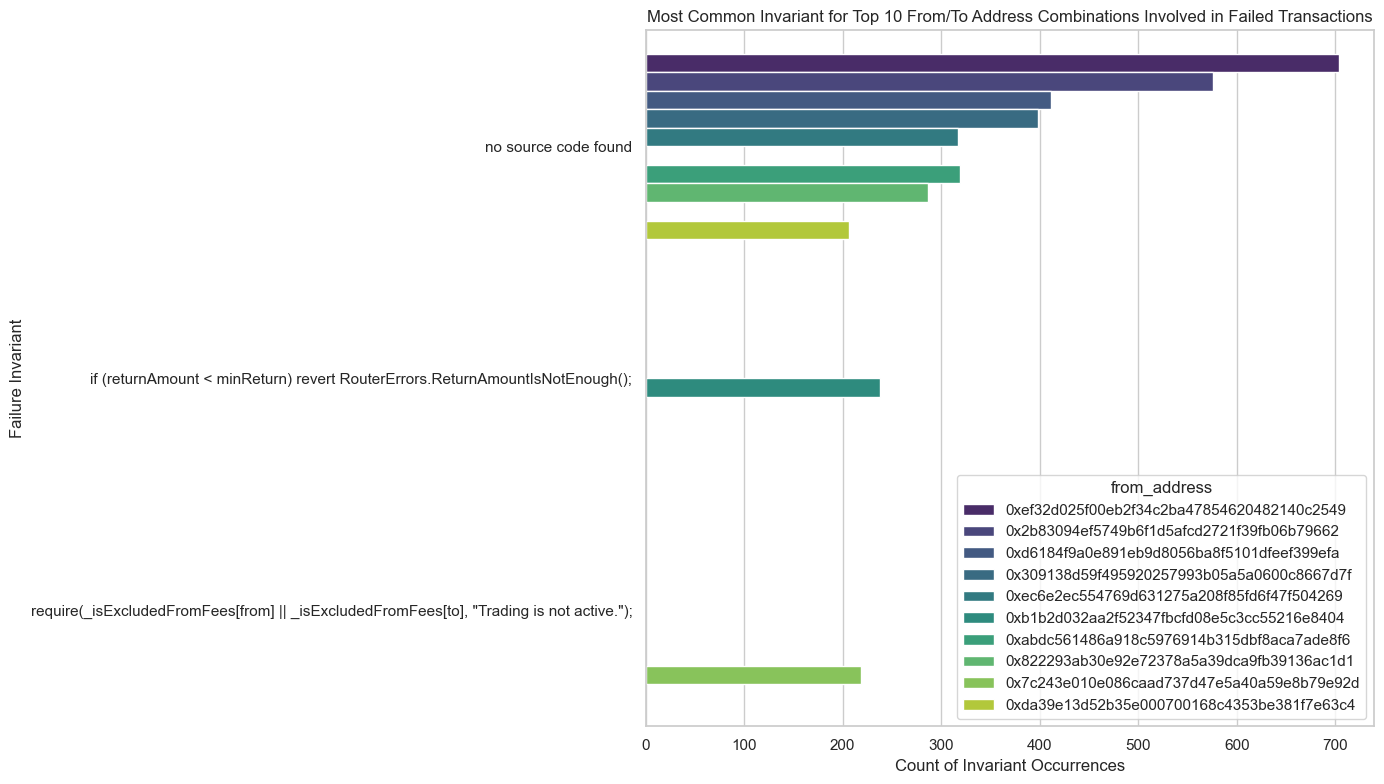

In [10]:
def plot_most_common_invariant_for_top_transactions(df):
    # Step 1: Get the top 10 most common (from_address, to_address) combinations
    transaction_counts = df.groupby(['from_address', 'to_address']).size().reset_index(name='failed_count')
    top_transactions = transaction_counts.sort_values(by='failed_count', ascending=False).head(10)

    # Step 2: For each of the top 10 (from_address, to_address) combinations, find the most common invariants
    invariant_counts = []

    for _, row in top_transactions.iterrows():
        # Filter the original DataFrame for the top (from_address, to_address) combination
        filtered_df = df[(df['from_address'] == row['from_address']) & (df['to_address'] == row['to_address'])]
        
        # Get the most common invariants for this combination
        invariant_counts_for_transaction = filtered_df['failure_invariant'].value_counts().head(1).reset_index()
        invariant_counts_for_transaction.columns = ['failure_invariant', 'count']
        
        # Add the (from_address, to_address) info to the result
        invariant_counts_for_transaction['from_address'] = row['from_address']
        invariant_counts_for_transaction['to_address'] = row['to_address']
        
        invariant_counts.append(invariant_counts_for_transaction)

    # Combine the lists into a single DataFrame
    invariant_counts_df = pd.concat(invariant_counts, ignore_index=True)

    # Step 3: Plot the most common invariants across the top 10 transactions
    sns.set(style="whitegrid")
    plt.figure(figsize=(14, 8))

    # Plot the barplot
    sns.barplot(x='count', y='failure_invariant', hue='from_address', data=invariant_counts_df, palette='viridis')

    plt.title('Most Common Invariant for Top 10 From/To Address Combinations Involved in Failed Transactions')
    plt.xlabel('Count of Invariant Occurrences')
    plt.ylabel('Failure Invariant')

    # Adjust layout for better spacing
    plt.tight_layout()

    # Show the plot
    plt.show()

# Example usage:
plot_most_common_invariant_for_top_transactions(df)


C:\Users\Melis\AppData\Local\Temp\ipykernel_29020\265447992.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='failed_count', y='failure_invariant', data=invariant_df, palette='viridis')


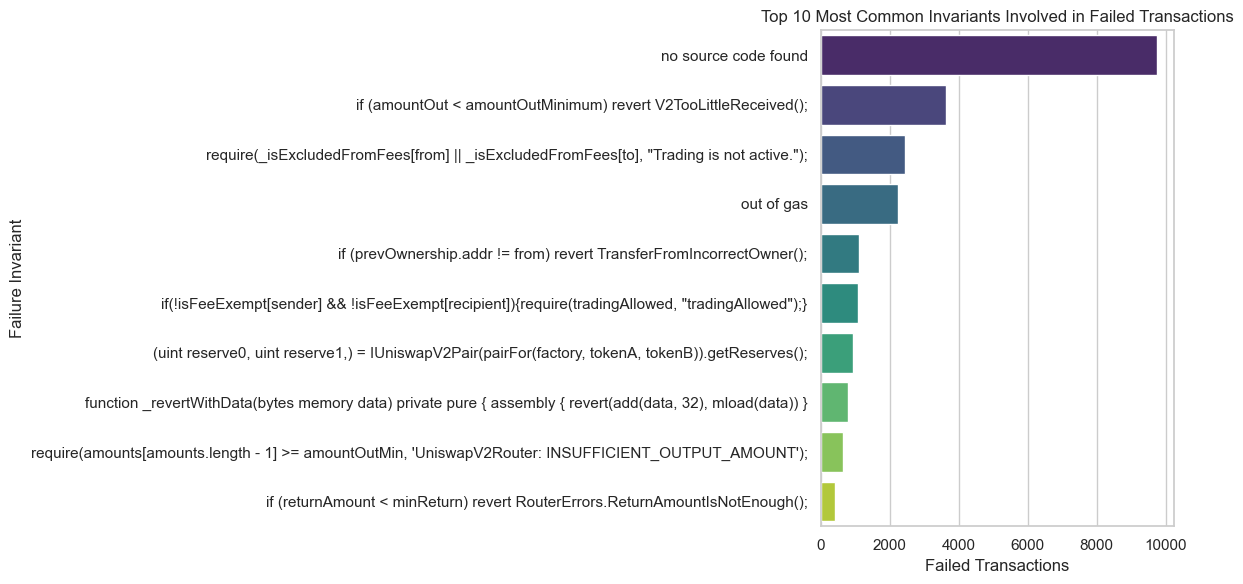

In [4]:
def plot_most_common_invariants(df, top_n=10):
    # Count the occurrences of each unique failure_invariant
    invariant_counts = df['failure_invariant'].value_counts().head(top_n)  # Top 'n' invariants

    # Convert the counts to a DataFrame for easier plotting
    invariant_df = invariant_counts.reset_index()
    invariant_df.columns = ['failure_invariant', 'failed_count']

    # Set seaborn style
    sns.set(style="whitegrid")

    # Plot the most common invariants involved in failed transactions
    plt.figure(figsize=(12, 6))
    sns.barplot(x='failed_count', y='failure_invariant', data=invariant_df, palette='viridis')

    plt.title(f'Top {top_n} Most Common Invariants Involved in Failed Transactions')
    plt.xlabel('Failed Transactions')
    plt.ylabel('Failure Invariant')

    # Adjust layout for better spacing
    plt.tight_layout()

    # Show the plot
    plt.show()

plot_most_common_invariants(df)

In [ ]:
# find out percentage of library code (service contracts) reversions 

C:\Users\Melis\AppData\Local\Temp\ipykernel_29020\3525009183.py:31: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


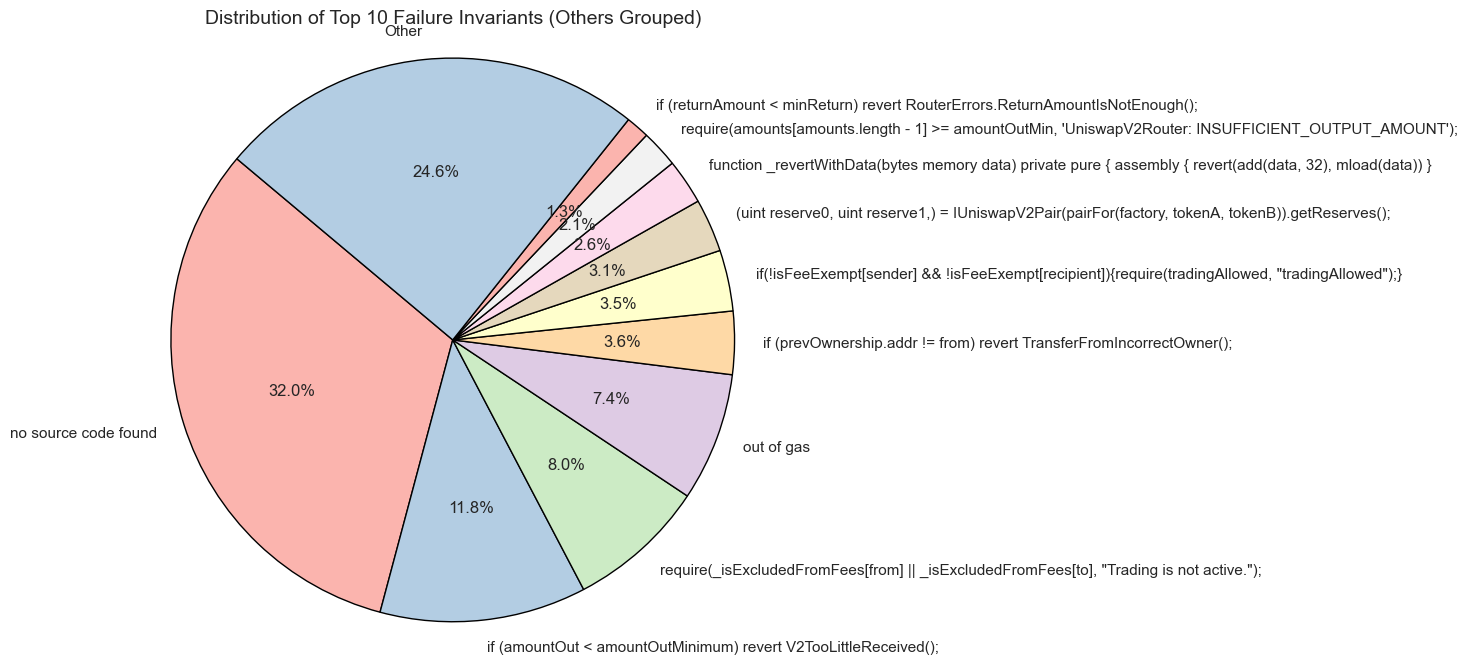

In [24]:
def plot_failure_invariants_pie(df, top_n=10):
    """
    Plots a pie chart of the top N failure invariants, grouping others into 'Other'.
    
    Parameters:
    df (pandas.DataFrame): DataFrame with a 'failure_invariant' column.
    top_n (int): Number of top failure invariants to show individually.
    """
    # Count occurrences of each invariant
    counts = df['failure_invariant'].value_counts()

    # Separate top N and group the rest
    top_counts = counts[:top_n]
    other_count = counts[top_n:].sum()
    
    if other_count > 0:
        top_counts['Other'] = other_count

    # Plot the pie chart
    plt.figure(figsize=(8, 8))
    plt.pie(
        top_counts,
        labels=top_counts.index,
        autopct='%1.1f%%',
        startangle=140,
        colors=plt.cm.Pastel1.colors,
        wedgeprops={'edgecolor': 'black'}
    )
    plt.title(f'Distribution of Top {top_n} Failure Invariants (Others Grouped)', fontsize=14)
    plt.axis('equal')
    plt.tight_layout()
    plt.show()
plot_failure_invariants_pie(df, top_n=10)

C:\Users\Melis\AppData\Local\Temp\ipykernel_22924\93568371.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_failure_counts.values, y=top_failure_counts.index, palette="viridis")


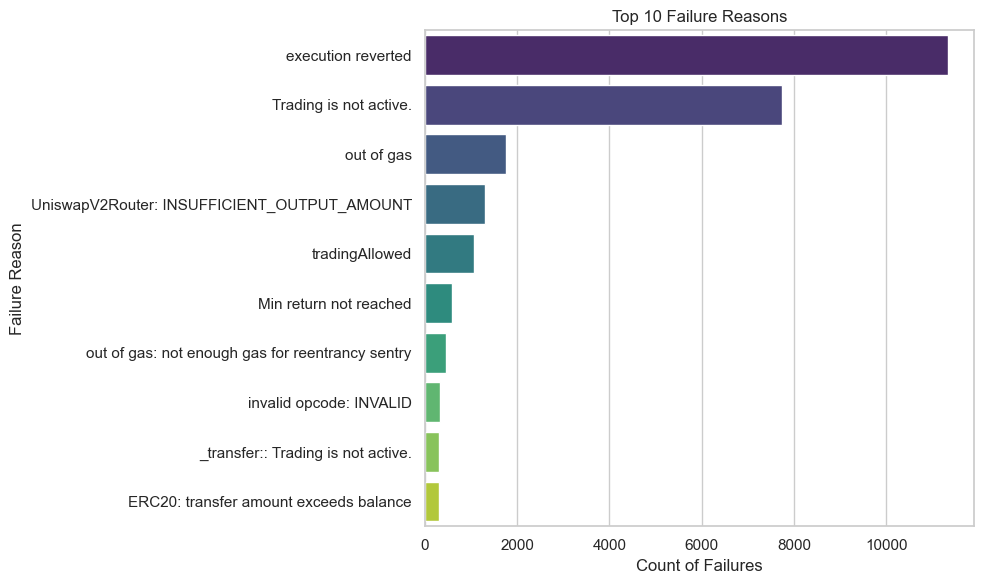

In [39]:
def failure_reason_frequency(df):
    failure_counts = df["failure_reason"].value_counts()
    top_failure_counts = failure_counts.head(10)
    
    # Set the style for the plot
    sns.set(style="whitegrid")
    
    # Create a bar plot for the top failure reasons
    plt.figure(figsize=(10, 6))
    sns.barplot(x=top_failure_counts.values, y=top_failure_counts.index, palette="viridis")
    
    # Set plot labels and title
    plt.title(f'Top 10 Failure Reasons')
    plt.xlabel('Count of Failures')
    plt.ylabel('Failure Reason')
    
    # Display the plot
    plt.tight_layout()
    plt.show()

failure_reason_frequency(df)


In [ ]:
# get rid of the duplicates and then redo plot --> check that the to addresses are different


C:\Users\Melis\AppData\Local\Temp\ipykernel_29020\230076676.py:21: UserWarning: Glyph 36824 (\N{CJK UNIFIED IDEOGRAPH-8FD8}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Melis\AppData\Local\Temp\ipykernel_29020\230076676.py:21: UserWarning: Glyph 19981 (\N{CJK UNIFIED IDEOGRAPH-4E0D}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Melis\AppData\Local\Temp\ipykernel_29020\230076676.py:21: UserWarning: Glyph 22815 (\N{CJK UNIFIED IDEOGRAPH-591F}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Melis\AppData\Local\Temp\ipykernel_29020\230076676.py:21: UserWarning: Glyph 20986 (\N{CJK UNIFIED IDEOGRAPH-51FA}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Melis\AppData\Local\Temp\ipykernel_29020\230076676.py:21: UserWarning: Glyph 25130 (\N{CJK UNIFIED IDEOGRAPH-622A}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Melis\AppData\Local\Temp\ipykernel_29020\230076676.py:21: UserWarning: Glyph 27490 (\N{CJK UNIFIED IDEOGRAPH-6B62}) missi

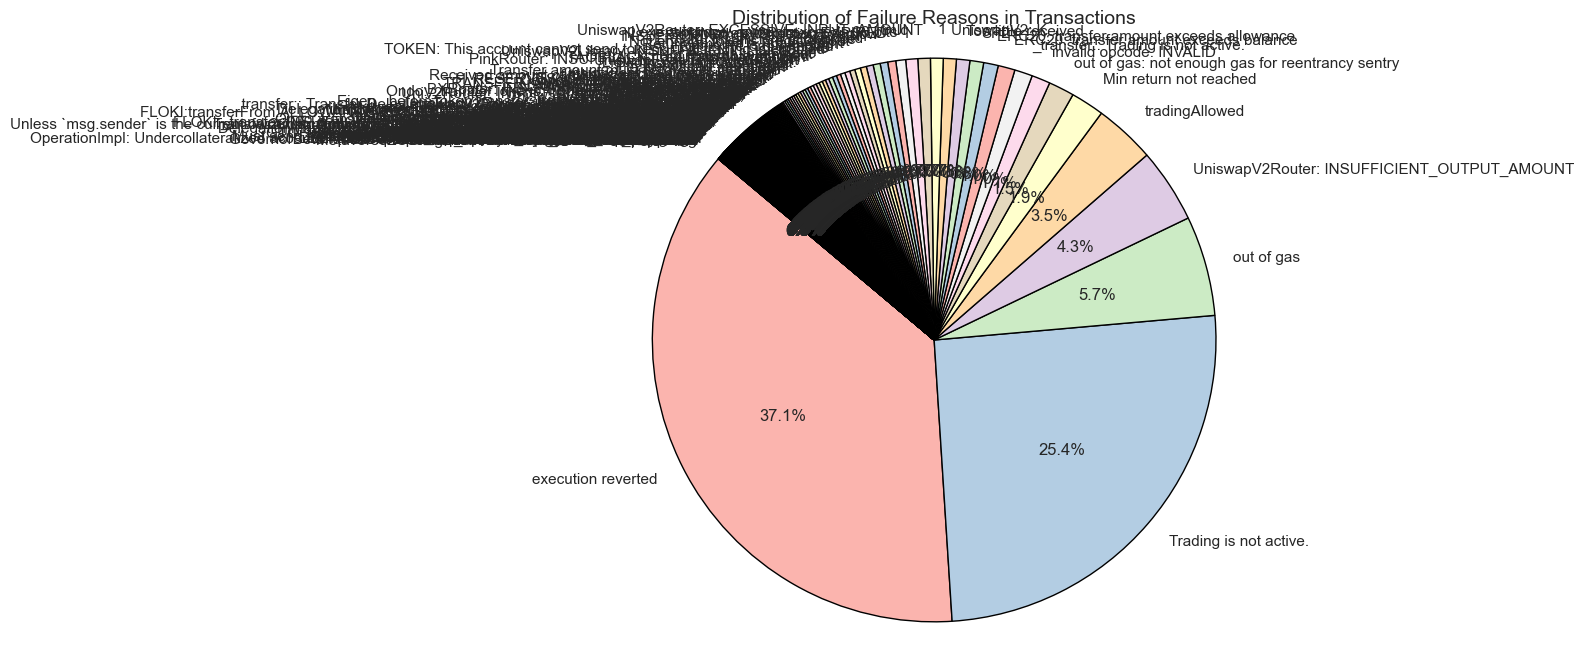

In [21]:
def plot_failure_reason_pie(df):
    """
    Plots a pie chart of the distribution of failure reasons in the transaction dataset.
    
    Parameters:
    df (pandas.DataFrame): DataFrame containing the 'failure_reason' column.
    """
    failure_counts = df['failure_reason'].value_counts()

    plt.figure(figsize=(8, 8))
    plt.pie(
        failure_counts,
        labels=failure_counts.index,
        autopct='%1.1f%%',
        startangle=140,
        colors=plt.cm.Pastel1.colors,
        wedgeprops={'edgecolor': 'black'}
    )
    plt.title('Distribution of Failure Reasons in Transactions', fontsize=14)
    plt.axis('equal')  # Keeps the pie chart circular
    plt.tight_layout()
    plt.show()

plot_failure_reason_pie(df)

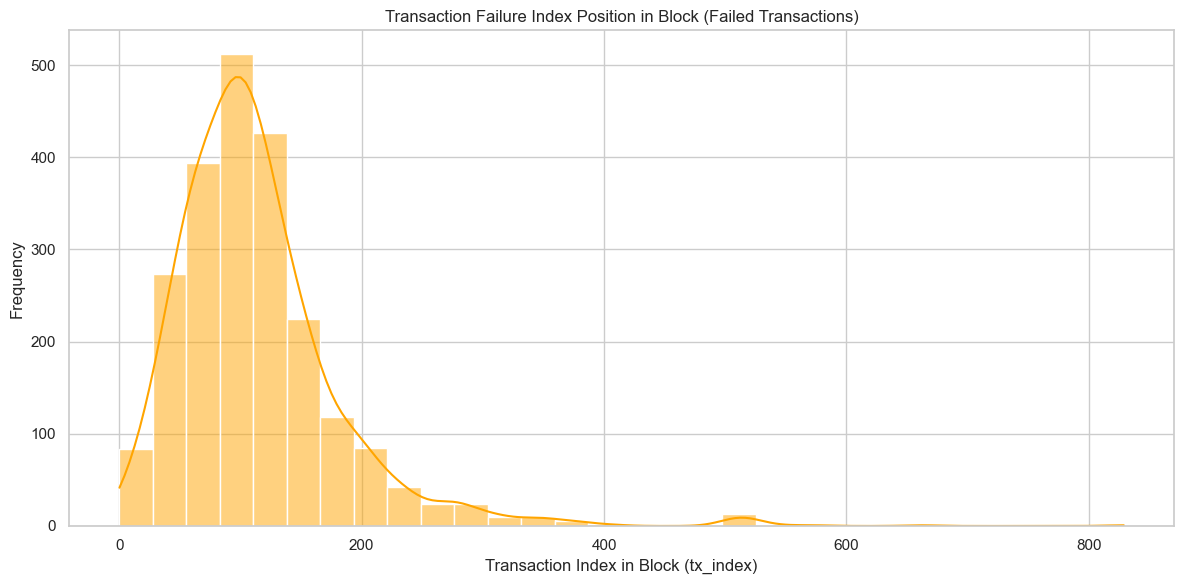


Transaction Index (tx_index) Analysis for Failed Transactions:
count    2249.000000
mean      113.957314
std        71.170526
min         0.000000
25%        69.000000
50%       102.000000
75%       138.000000
max       829.000000
Name: tx_index, dtype: float64


In [33]:
def analyze_failed_tx_index(df):
    # Filter the failed transactions (e.g., "out of gas" or other failure reasons)
    failed_transactions_df = df[df['failure_reason'].str.contains('out of gas', case=False, na=False)]

    # Check if there are any failed transactions
    if failed_transactions_df.empty:
        print("No failed transactions found.")
        return
    
    # Plot the distribution of tx_index for failed transactions
    sns.set(style="whitegrid")
    plt.figure(figsize=(12, 6))

    # Plot a histogram of the tx_index
    sns.histplot(failed_transactions_df['tx_index'], kde=True, color='orange', bins=30)

    plt.title('Transaction Failure Index Position in Block (Failed Transactions)')
    plt.xlabel('Transaction Index in Block (tx_index)')
    plt.ylabel('Frequency')

    # Show the plot
    plt.tight_layout()
    plt.show()

    # Additional analysis: Describe the tx_index distribution
    print(f"\nTransaction Index (tx_index) Analysis for Failed Transactions:")
    print(failed_transactions_df['tx_index'].describe())

analyze_failed_tx_index(df)


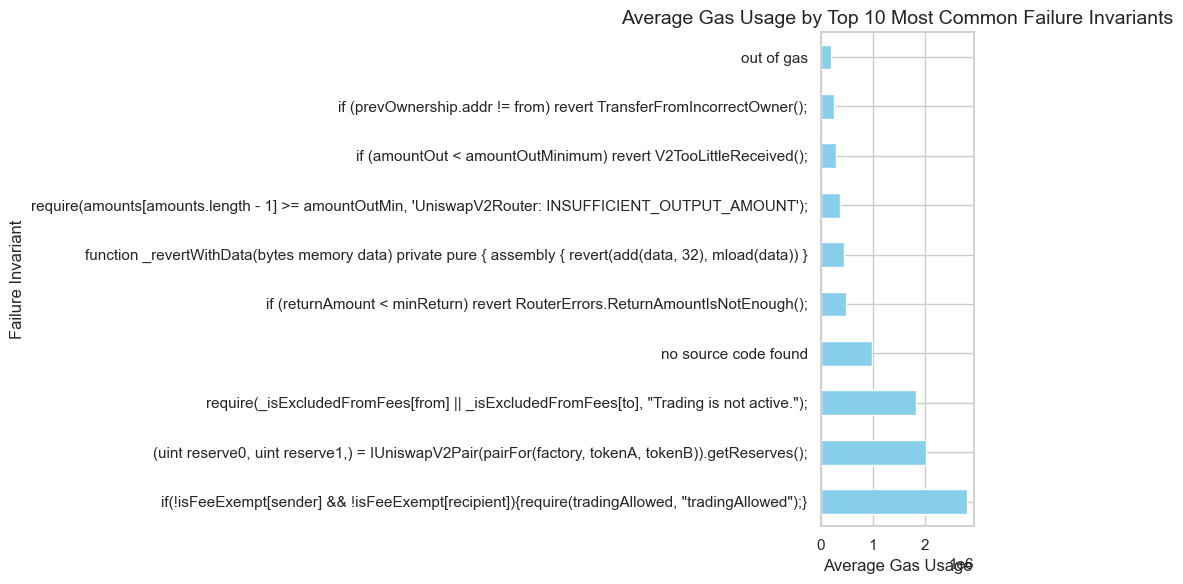

In [20]:
def plot_avg_gas_by_failure_invariant(df):
    top_10_invariants = df['failure_invariant'].value_counts().head(10).index
    
    # Filter the DataFrame to include only the top 10 failure invariants
    filtered_df = df[df['failure_invariant'].isin(top_10_invariants)]
    
    # Group by 'failure_invariant' and calculate the average gas usage
    avg_gas_by_invariant = filtered_df.groupby('failure_invariant')['gas'].mean().sort_values(ascending=False)
    
    # Plotting the bar chart
    plt.figure(figsize=(10, 6))
    avg_gas_by_invariant.plot(kind='barh', color='skyblue')

    plt.title('Average Gas Usage by Top 10 Most Common Failure Invariants', fontsize=14)
    plt.xlabel('Average Gas Usage', fontsize=12)
    plt.ylabel('Failure Invariant', fontsize=12)
    plt.tight_layout()
    plt.show()

plot_avg_gas_by_failure_invariant(df)

C:\Users\Melis\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\seaborn\utils.py:61: UserWarning: Glyph 36824 (\N{CJK UNIFIED IDEOGRAPH-8FD8}) missing from font(s) Arial.
  fig.canvas.draw()
C:\Users\Melis\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\seaborn\utils.py:61: UserWarning: Glyph 19981 (\N{CJK UNIFIED IDEOGRAPH-4E0D}) missing from font(s) Arial.
  fig.canvas.draw()
C:\Users\Melis\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\seaborn\utils.py:61: UserWarning: Glyph 22815 (\N{CJK UNIFIED IDEOGRAPH-591F}) missing from font(s) Arial.
  fig.canvas.draw()
C:\Users\Melis\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\seaborn\utils.py:61: UserWarning: Glyph 20986 (\N{CJK UNIFIED IDEOGRAPH

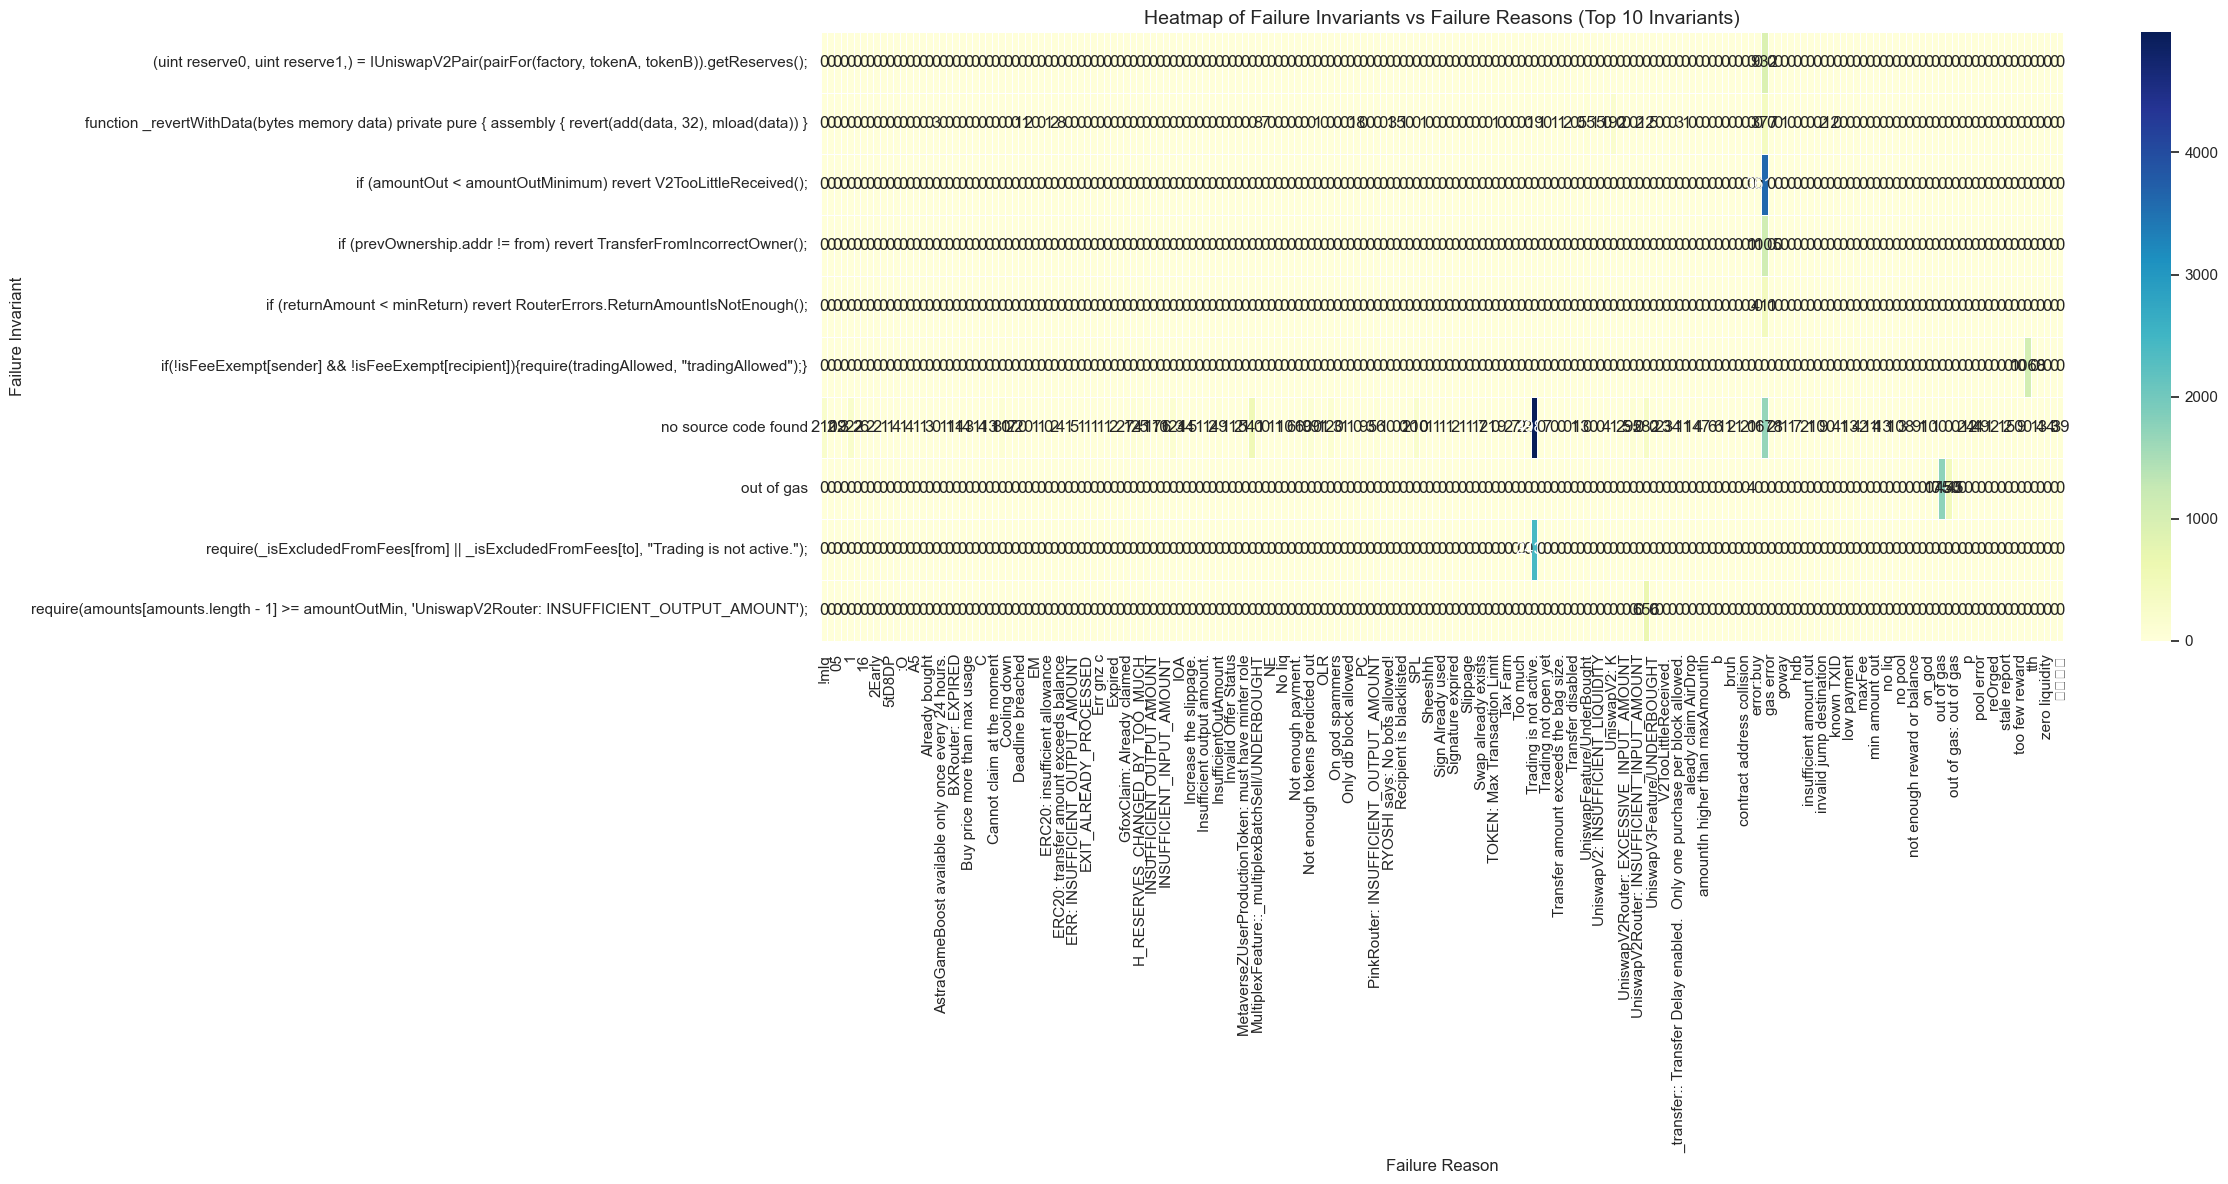

In [29]:
def plot_failure_invariant_reason_heatmap(df, top_n=10):
    """
    Plots a heatmap showing the relationship between failure invariants and failure reasons.
    
    Parameters:
    df (pandas.DataFrame): DataFrame with 'failure_invariant' and 'failure_reason' columns.
    top_n (int): Number of top failure invariants to include.
    """
    # Select top N most frequent invariants
    top_invariants = df['failure_invariant'].value_counts().head(top_n).index
    filtered_df = df[df['failure_invariant'].isin(top_invariants)]

    # Create a pivot table (counts of reasons per invariant)
    heatmap_data = pd.crosstab(filtered_df['failure_invariant'], filtered_df['failure_reason'])

    # Plot heatmap
    plt.figure(figsize=(24, 12))
    sns.heatmap(heatmap_data, annot=True, fmt='d', cmap='YlGnBu', linewidths=0.5)

    plt.title(f'Heatmap of Failure Invariants vs Failure Reasons (Top {top_n} Invariants)', fontsize=14)
    plt.xlabel('Failure Reason', fontsize=12)
    plt.ylabel('Failure Invariant', fontsize=12)
    plt.tight_layout()
    plt.show()

plot_failure_invariant_reason_heatmap(df)


C:\Users\Melis\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\seaborn\utils.py:61: UserWarning: Glyph 36824 (\N{CJK UNIFIED IDEOGRAPH-8FD8}) missing from font(s) Arial.
  fig.canvas.draw()
C:\Users\Melis\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\seaborn\utils.py:61: UserWarning: Glyph 19981 (\N{CJK UNIFIED IDEOGRAPH-4E0D}) missing from font(s) Arial.
  fig.canvas.draw()
C:\Users\Melis\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\seaborn\utils.py:61: UserWarning: Glyph 22815 (\N{CJK UNIFIED IDEOGRAPH-591F}) missing from font(s) Arial.
  fig.canvas.draw()
C:\Users\Melis\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\seaborn\utils.py:61: UserWarning: Glyph 20986 (\N{CJK UNIFIED IDEOGRAPH

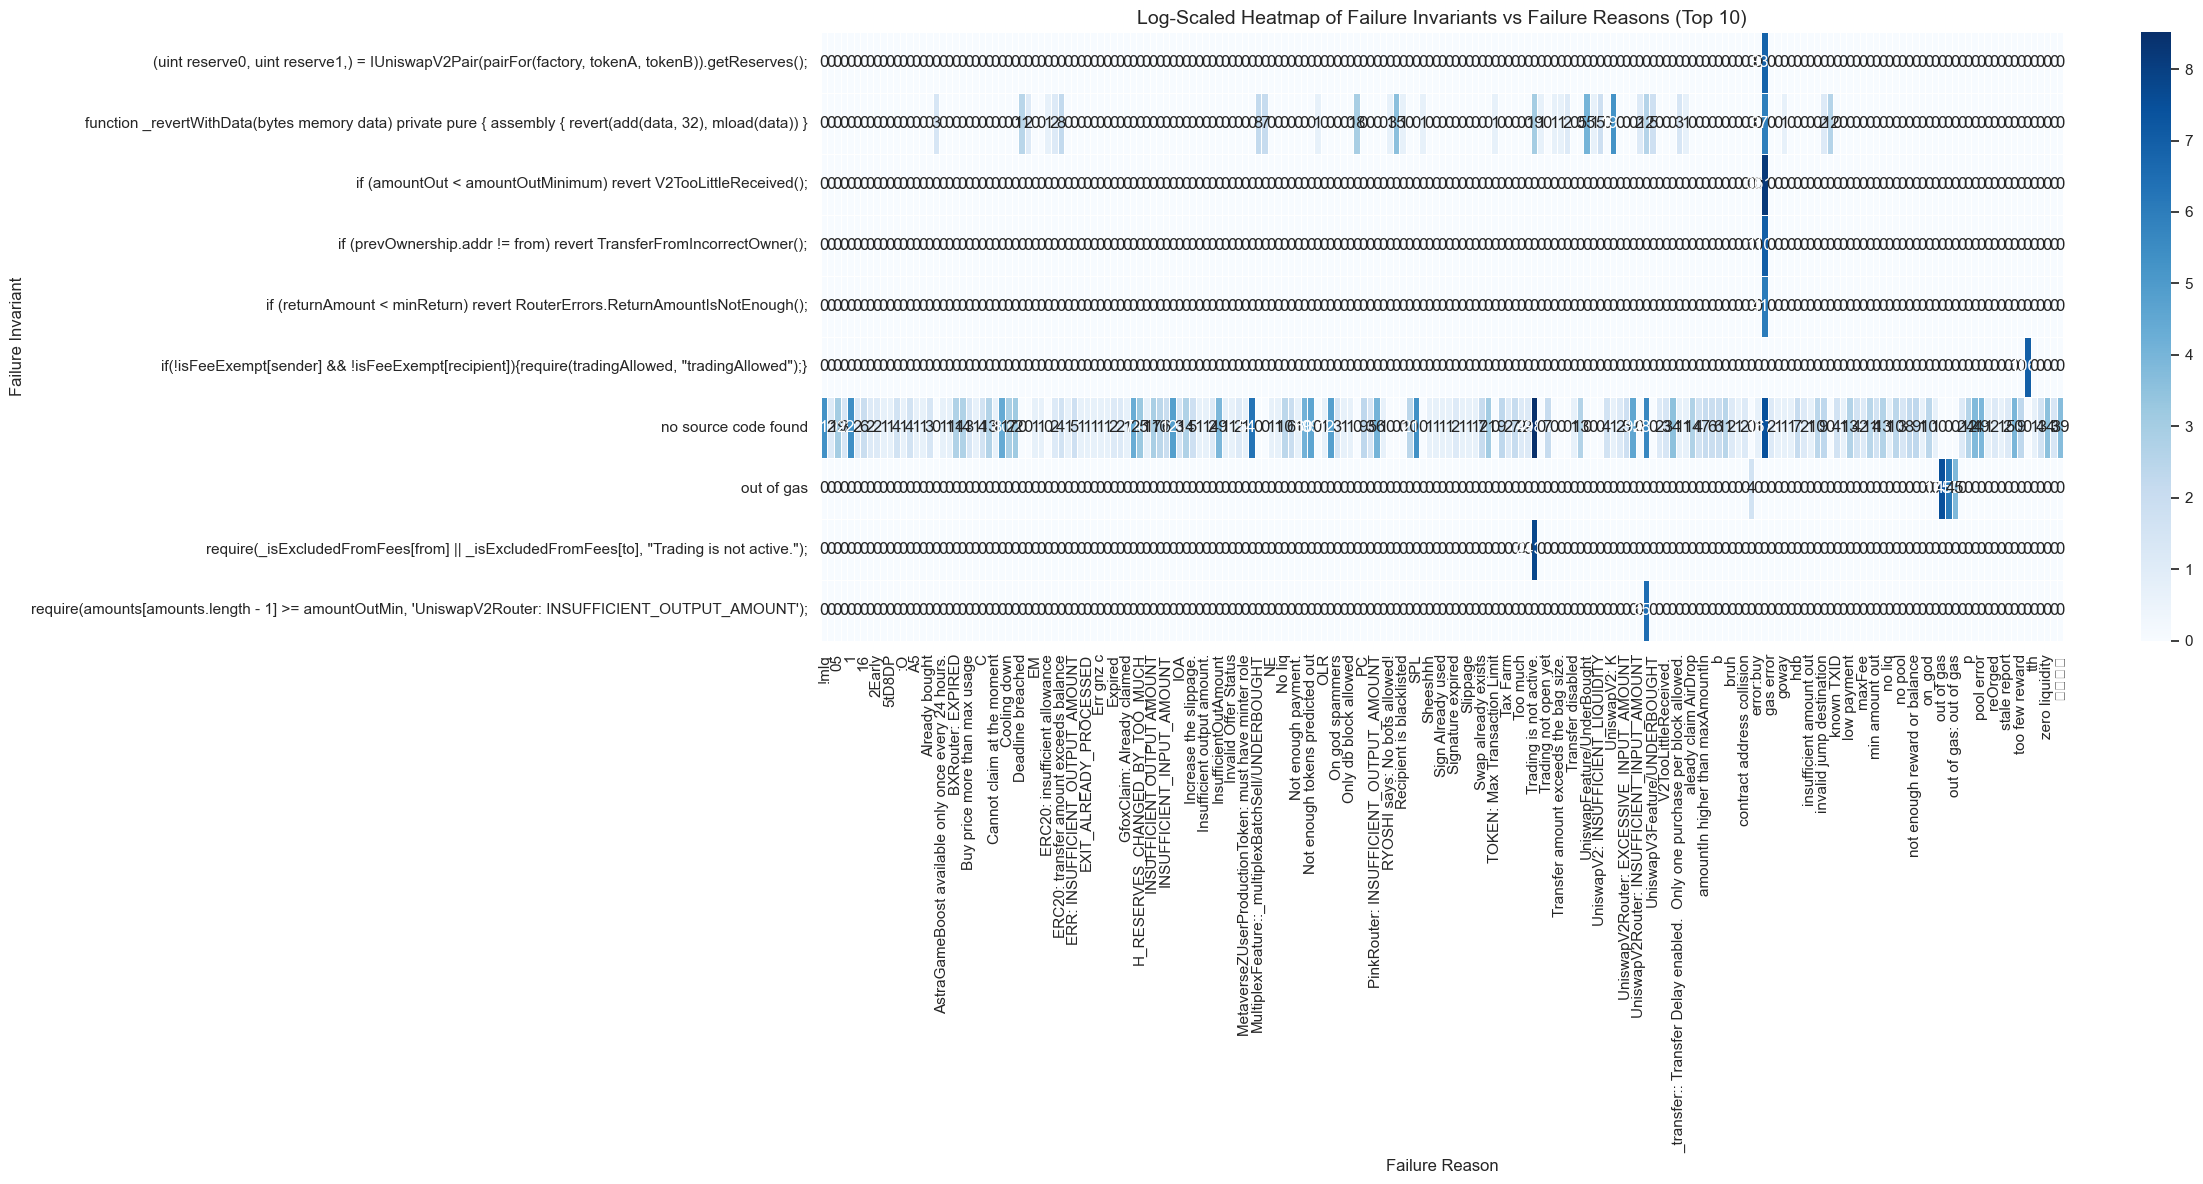

In [31]:
import numpy as np

def plot_failure_invariant_reason_heatmap_log(df, top_n=10):
    """
    Plots a heatmap of failure invariants vs failure reasons using a log scale to highlight variation.
    
    Parameters:
    df (pandas.DataFrame): DataFrame with 'failure_invariant' and 'failure_reason' columns.
    top_n (int): Number of top failure invariants to include.
    """
    top_invariants = df['failure_invariant'].value_counts().head(top_n).index
    filtered_df = df[df['failure_invariant'].isin(top_invariants)]

    heatmap_data = pd.crosstab(filtered_df['failure_invariant'], filtered_df['failure_reason'])

    # Apply log1p to shift and log-scale the values
    log_heatmap_data = np.log1p(heatmap_data)

    plt.figure(figsize=(24, 12))
    sns.heatmap(log_heatmap_data, annot=heatmap_data, fmt='d', cmap='Blues', linewidths=0.5)

    plt.title(f'Log-Scaled Heatmap of Failure Invariants vs Failure Reasons (Top {top_n})', fontsize=14)
    plt.xlabel('Failure Reason', fontsize=12)
    plt.ylabel('Failure Invariant', fontsize=12)
    plt.tight_layout()
    plt.show()
plot_failure_invariant_reason_heatmap_log(df)

<Figure size 3000x3000 with 0 Axes>

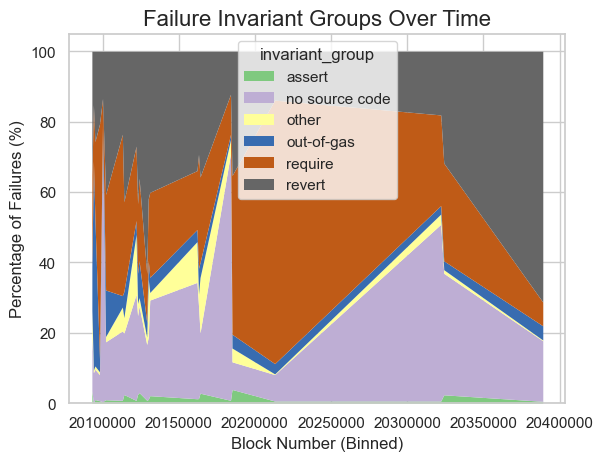

In [39]:
def plot_failure_invariant_groups_over_time(df, bin_size=1000):
    """
    Groups failure_invariants into categories and shows how they evolve over time
    using a stacked area chart.

    Parameters:
    df (pandas.DataFrame): Must contain 'failure_invariant' and 'block_number'.
    bin_size (int): How many blocks to group together for time bins.
    """
    df_clean = df.dropna(subset=['failure_invariant', 'block_number']).copy()

    # Group failure_invariant into categories
    def categorize_invariant(inv):
        inv = str(inv).lower()
        if 'assert' in inv:
            return 'assert'
        elif 'require' in inv:
            return 'require'
        elif 'revert' in inv:
            return 'revert'
        elif 'out' in inv or 'gas' in inv:
            return 'out-of-gas'
        elif 'no source' in inv:
            return 'no source code'
        else:
            return 'other'

    df_clean['invariant_group'] = df_clean['failure_invariant'].apply(categorize_invariant)

    # Bin by block number
    df_clean['block_bin'] = (df_clean['block_number'] // bin_size) * bin_size

    # Count number of each invariant group per time bin
    grouped = df_clean.groupby(['block_bin', 'invariant_group']).size().unstack(fill_value=0)

    # Normalize to percentages
    percentages = grouped.div(grouped.sum(axis=1), axis=0) * 100

    # Plot the stacked area chart
    plt.figure(figsize=(30, 30))
    percentages.plot.area(colormap='Accent', linewidth=0)
    plt.gca().xaxis.set_major_formatter(ticker.FormatStrFormatter('%d'))


    plt.title('Failure Invariant Groups Over Time', fontsize=16)
    plt.xlabel('Block Number (Binned)', fontsize=12)
    plt.ylabel('Percentage of Failures (%)')

plot_failure_invariant_groups_over_time(df)


C:\Users\Melis\AppData\Local\Temp\ipykernel_29020\2403048969.py:17: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


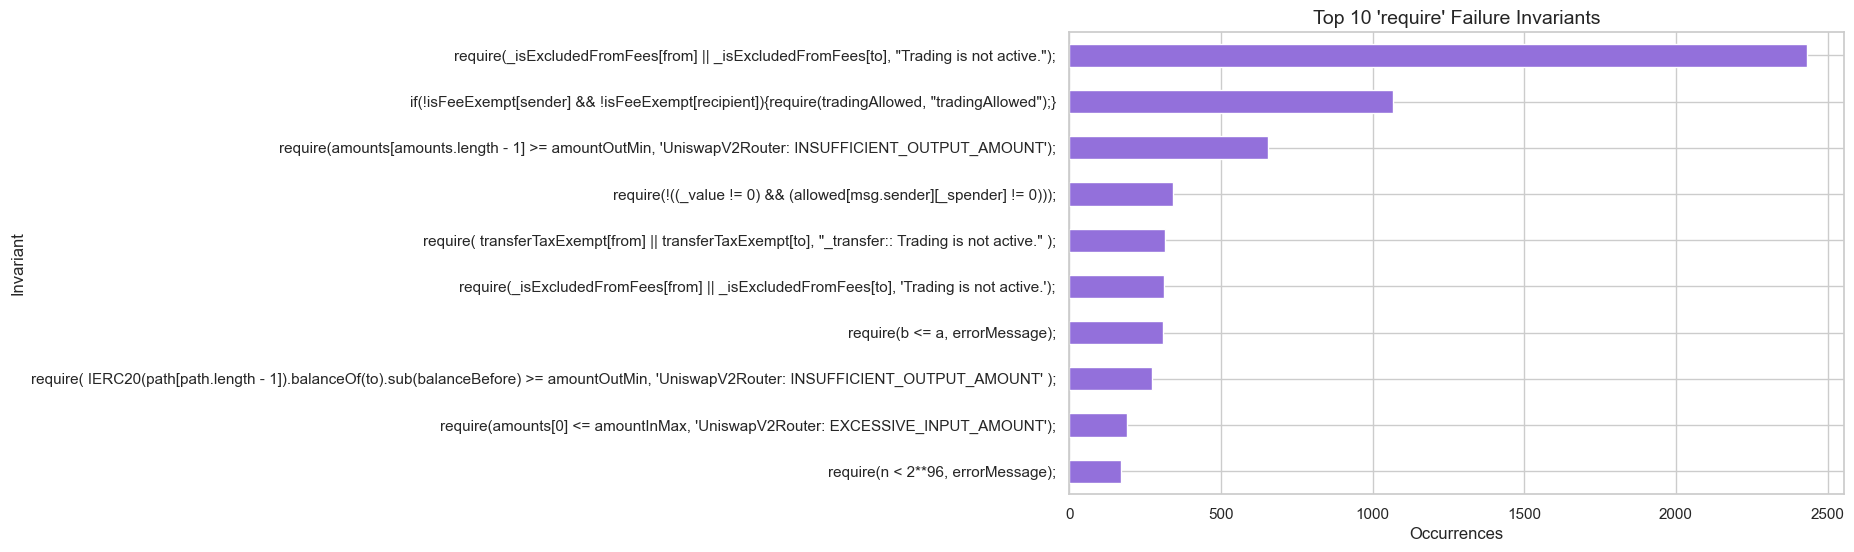

In [41]:
def plot_top_require_invariants(df, top_n=10):
    """
    Plots a bar chart of the top N most common 'require' invariants.

    Parameters:
    df_require (pandas.DataFrame): Filtered to only 'require' failures.
    top_n (int): Number of top require patterns to show.
    """
    df_require = df[df['failure_invariant'].str.contains('require', case=False, na=False)].copy()
    top = df_require['failure_invariant'].value_counts().head(top_n)

    plt.figure(figsize=(10, 6))
    top.sort_values().plot(kind='barh', color='mediumpurple')
    plt.title(f"Top {top_n} 'require' Failure Invariants", fontsize=14)
    plt.xlabel("Occurrences")
    plt.ylabel("Invariant")
    plt.tight_layout()
    plt.show()
plot_top_require_invariants(df)

C:\Users\Melis\AppData\Local\Temp\ipykernel_25120\4084097364.py:26: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


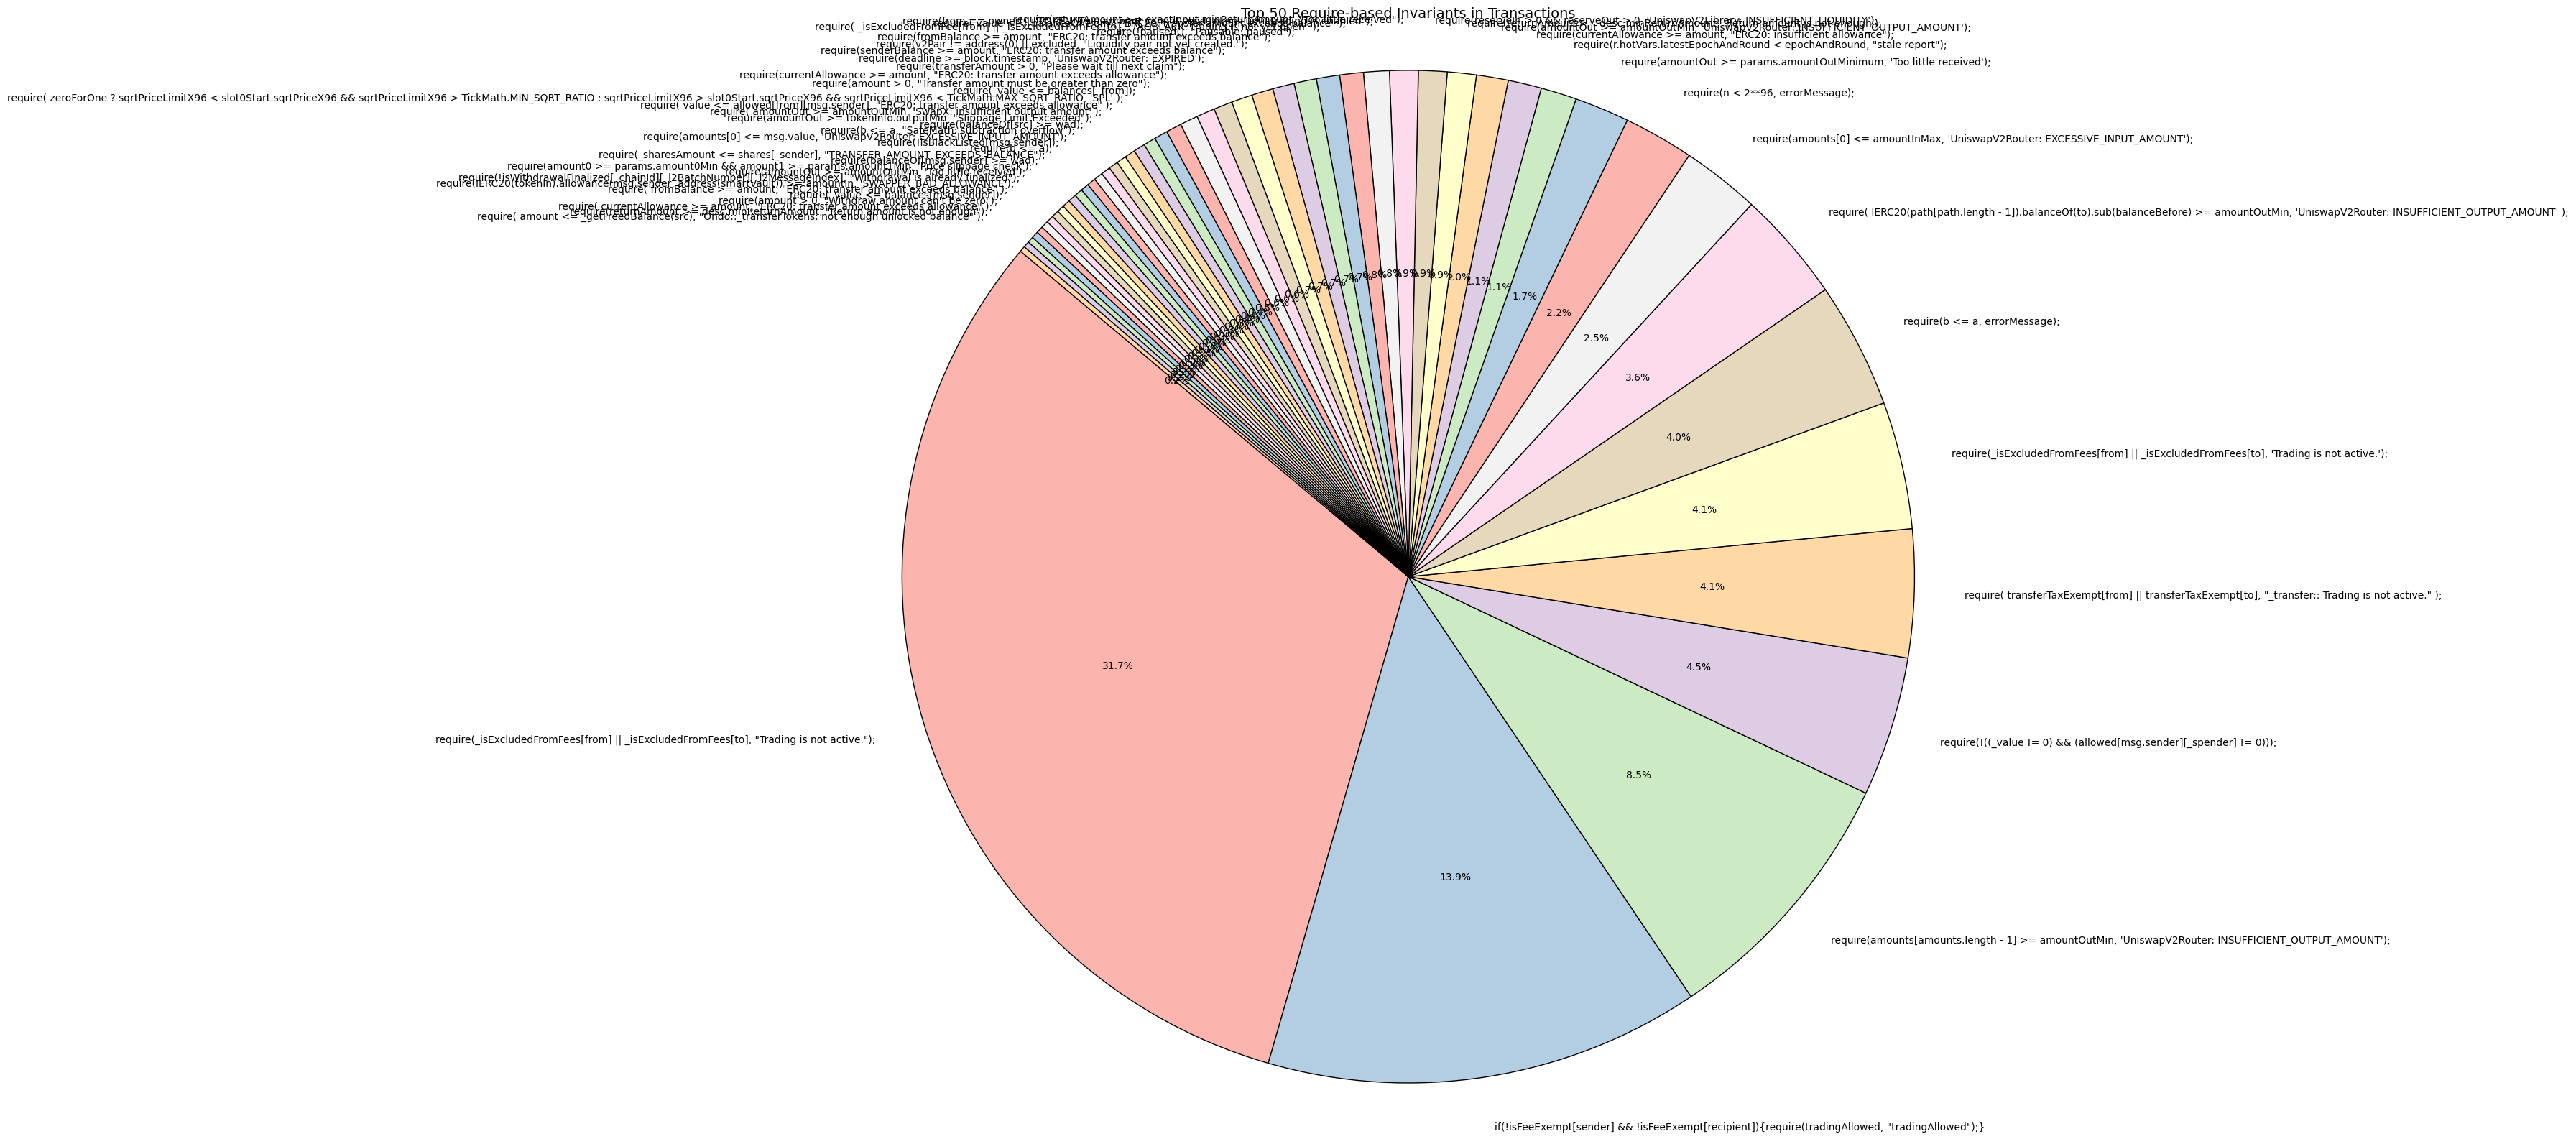

In [7]:
def plot_require_pie(df, top_n=10):
    """
    Plots a pie chart of the top N 'require' failure_invariants.

    Parameters:
    df (pandas.DataFrame): Full transaction dataset.
    top_n (int): Number of top require-based invariants to include in the pie.
    """
    # Filter only 'require' failure_invariants
    df_require = df[df['failure_invariant'].str.contains('require', case=False, na=False)]

    # Get value counts of the most common require invariants
    require_counts = df_require['failure_invariant'].value_counts().head(top_n)

    plt.figure(figsize=(20, 20))
    plt.pie(
        require_counts,
        labels=require_counts.index,
        autopct='%1.1f%%',
        startangle=140,
        colors=plt.cm.Pastel1.colors[:top_n],
        wedgeprops={'edgecolor': 'black'}
    )
    plt.title(f'Top {top_n} Require-based Invariants in Transactions', fontsize=14)
    plt.axis('equal')  # Keeps the pie chart circular
    plt.tight_layout()
    plt.show()

plot_require_pie(df, top_n=50)


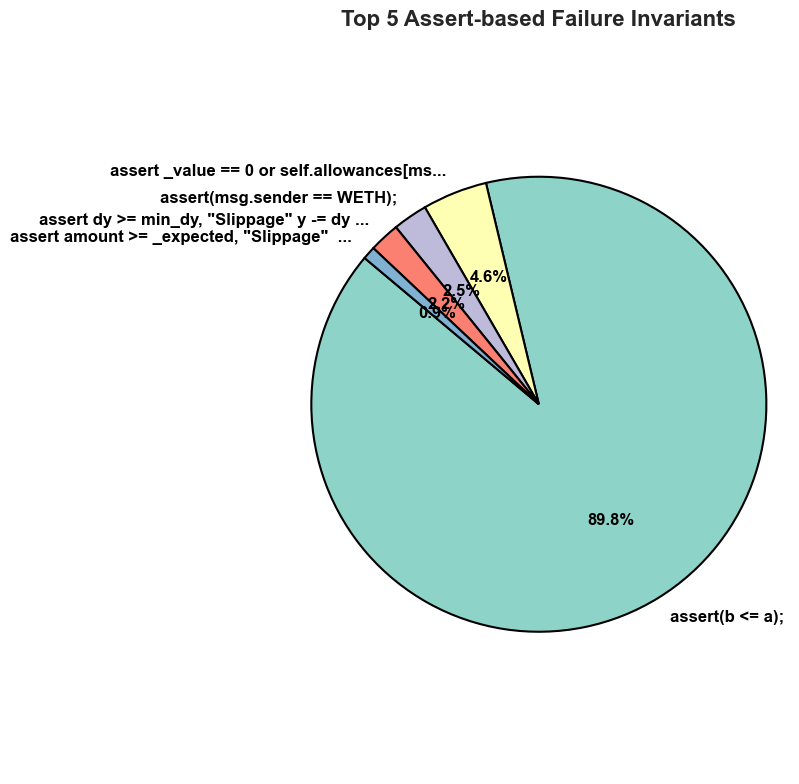

In [32]:
def plot_assert_pie(df, top_n=10):
    """
    Plots a pie chart of the top N 'assert' failure_invariants in a scientific-friendly style.
    
    Parameters:
    df (pandas.DataFrame): Full transaction dataset.
    top_n (int): Number of top 'assert' failure_invariants to include in the pie.
    """
    # Filter only 'assert' failure_invariants
    df_assert = df[df['failure_invariant'].str.contains('assert', case=False, na=False)]

    # Get value counts of the most common assert invariants
    assert_counts = df_assert['failure_invariant'].value_counts().head(top_n)
    
    # Create readable labels
    labels = assert_counts.index
    labels = [label[:40] + '...' if len(label) > 40 else label for label in labels]  # Truncate if too long

    # Plotting
    plt.figure(figsize=(8, 8))  # Square figure for better aspect ratio
    plt.pie(
        assert_counts,
        labels=labels,
        autopct='%1.1f%%',
        startangle=140,
        colors=sns.color_palette("Set3", n_colors=top_n),  # More distinct colors from seaborn
        wedgeprops={'edgecolor': 'black', 'linewidth': 1.5},
        textprops={'fontsize': 12, 'weight': 'bold', 'color': 'black'},  # Better font readability
    )

    # Title and layout adjustments
    plt.title(f'Top {top_n} Assert-based Failure Invariants', fontsize=16, weight='bold')
    plt.axis('equal')  # Ensures the pie chart is circular
    plt.tight_layout()  # Avoids overlap and cut-off text

    # Show the plot
    plt.show()

plot_assert_pie(df, top_n=5)


Total `assert(b <= a);` failures: 292
to_address
0xdac17f958d2ee523a2206206994597c13d831ec7    220
0x881d40237659c251811cec9c364ef91dc08d300c     48
0x16a734ad909d444f6c5914d0f827ee410cf9d63f      5
0x514910771af9ca656af840dff83e8264ecf986ca      4
0xe592427a0aece92de3edee1f18e0157c05861564      2
0x68b3465833fb72a70ecdf485e0e4c7bd8665fc45      2
0x68a47fe1cf42eba4a030a10cd4d6a1031ca3ca0a      1
0x3fc91a3afd70395cd496c647d5a6cc9d4b2b7fad      1
0x111111125421ca6dc452d289314280a0f8842a65      1
0x5f515f6c524b18ca30f7783fb58dd4be2e9904ec      1
Name: count, dtype: int64


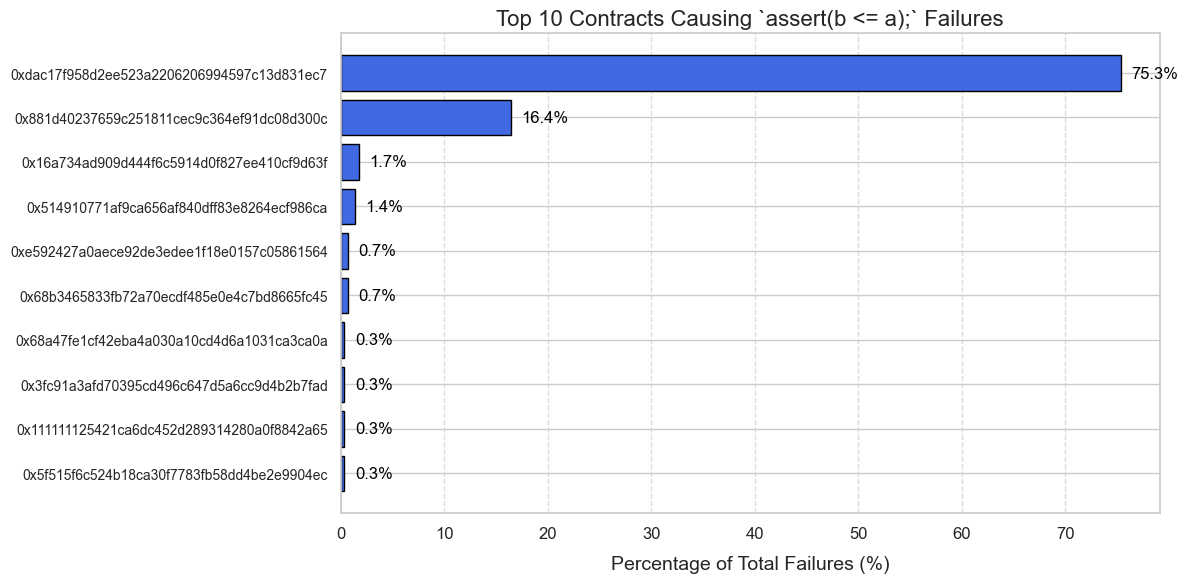

In [44]:
def plot_assert_b_leq_a_failure_distribution(df, top_n=10):
    target_invariant = 'assert(b <= a);'
    df_filtered = df[df['failure_invariant'].str.strip().str.lower() == target_invariant.lower()]

    if df_filtered.empty:
        print("No transactions found with invariant: assert(b <= a);")
        return

    total_failures = len(df_filtered)
    print(f"Total `assert(b <= a);` failures: {total_failures:,}")
    to_counts = df_filtered['to_address'].value_counts()
    top_to_counts = to_counts.head(top_n)
    print(top_to_counts)
    top_to_percent = (top_to_counts / total_failures) * 100

    sns.set(style="whitegrid")
    plt.figure(figsize=(12, 6))

    labels = top_to_percent.index
    bars = plt.barh(labels, top_to_percent, color='royalblue', edgecolor='black')

    for i, v in enumerate(top_to_percent):
        plt.text(v + 1, i, f'{v:.1f}%', va='center', ha='left', fontsize=12, color='black')

    plt.xlabel('Percentage of Total Failures (%)', fontsize=14, labelpad=10)
    plt.title(f'Top {top_n} Contracts Causing `assert(b <= a);` Failures', fontsize=16)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=10)
    plt.gca().invert_yaxis()  # Invert Y-axis to have the top value at the top

    # Tight layout to avoid cut-off
    plt.tight_layout()

    # Add a grid and styling for clarity
    plt.grid(axis='x', linestyle='--', alpha=0.7)

    # Display the plot
    plt.show()

plot_assert_b_leq_a_failure_distribution(df)


Empty DataFrame
Columns: [hash, failure_reason, block_number, from_address, to_address, tx_input, gas, gas_price, gas_limit, value, tx_index, failure_message, failure_invariant, gas_price_category]
Index: []


30533